# Bank Customer Churn Analysis

## Project Overview

Customer churn represents customers who stop using a bank's services. Retaining existing customers is significantly cheaper than acquiring new ones, making churn prediction a critical business problem.

In this project, I explore a dataset of 10,000 bank customers to understand what drives churn and build a predictive model that could help the bank take proactive measures.

The analysis begins with exploratory data analysis (EDA) to examine customer demographics, financial characteristics, and account behavior. This step helps identify patterns and relationships that may influence customer retention.

Next, the dataset is prepared for modeling through data cleaning and feature engineering. Machine learning models are then trained and evaluated to predict the likelihood of customer churn, with performance assessed using metrics such as ROC-AUC, precision, recall, and confusion matrices.

Finally, the model is used to estimate churn probabilities for all customers, allowing them to be segmented into risk tiers. This enables the identification of high-risk customers and provides insight into the potential financial impact of churn.

The goal of this project is not only to predict churn but also to demonstrate how data-driven insights can support targeted retention strategies in a banking environment.

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay, 
                                precision_recall_curve, average_precision_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
import xgboost as xgb

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

## 1. Load & Explore the Data

In [2]:
df = pd.read_csv("Customer-Churn-Records.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


**Target Variable:** `Exited`  
- `1` → Customer Churned  
- `0` → Customer Retained

In [3]:
print("Shape:", df.shape)
df.info()

Shape: (10000, 18)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  str    
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  str    
 5   Gender              10000 non-null  str    
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 1

In [4]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5000.50,2886.90,1.00,2500.75,5000.50,7500.25,10000.00
CustomerId,10000.0,15690940.57,71936.19,15565701.00,15628528.25,15690738.00,15753233.75,15815690.00
CreditScore,10000.0,650.53,96.65,350.00,584.00,652.00,718.00,850.00
Age,10000.0,38.92,10.49,18.00,32.00,37.00,44.00,92.00
Tenure,10000.0,5.01,2.89,0.00,3.00,5.00,7.00,10.00
Balance,10000.0,76485.89,62397.41,0.00,0.00,97198.54,127644.24,250898.09
NumOfProducts,10000.0,1.53,0.58,1.00,1.00,1.00,2.00,4.00
HasCrCard,10000.0,0.71,0.46,0.00,0.00,1.00,1.00,1.00
IsActiveMember,10000.0,0.52,0.50,0.00,0.00,1.00,1.00,1.00
EstimatedSalary,10000.0,100090.24,57510.49,11.58,51002.11,100193.92,149388.25,199992.48


**Initial Observations**

- Dataset contains 10,000 customers with 18 features and no missing values.
- Churn rate is ~20% which shows a moderately imbalanced classification problem.
- ~25% of customers have zero balance and are also inactive members which may be a sign of disengagement.
- ~48% are inactive members which can likely be a churn driver.
- ~20% have raised complaints, nearly identical to churn rate, which can be a strong link.
- Average satisfaction score is ~3/5, shows there is room for service improvement.

## 2. Data Cleaning

In [5]:
# Drop identifier columns — no predictive value
df_clean = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

# Standardize column names
df_clean = df_clean.rename(columns={
    "Satisfaction Score": "SatisfactionScore",
    "Card Type": "CardType",
    "Point Earned": "PointEarned"
})

df_clean.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,SatisfactionScore,CardType,PointEarned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [6]:
# Check for missing values
print("Missing values:\n", df_clean.isnull().sum())

# Check for logical anomalies
invalid = df_clean[
    (df_clean["Age"] < 18) |
    (df_clean["CreditScore"] < 300) |
    (df_clean["Balance"] < 0) |
    (df_clean["EstimatedSalary"] <= 0)
]
print(f"\nInvalid records: {len(invalid)}")

Missing values:
 CreditScore          0
Geography            0
Gender               0
Age                  0
Tenure               0
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited               0
Complain             0
SatisfactionScore    0
CardType             0
PointEarned          0
dtype: int64

Invalid records: 0


In [7]:
# Saved the cleaned csv
df_clean.to_csv("churn_cleaned.csv", index=False)
df_clean = pd.read_csv("churn_cleaned.csv")
print("Cleaned data saved. Shape:", df_clean.shape)

Cleaned data saved. Shape: (10000, 15)


In [8]:
# Define color palette
palette = ["#f0e7ff", "#cfb4f7", "#6982c7", "#9e379f", "#493267"]

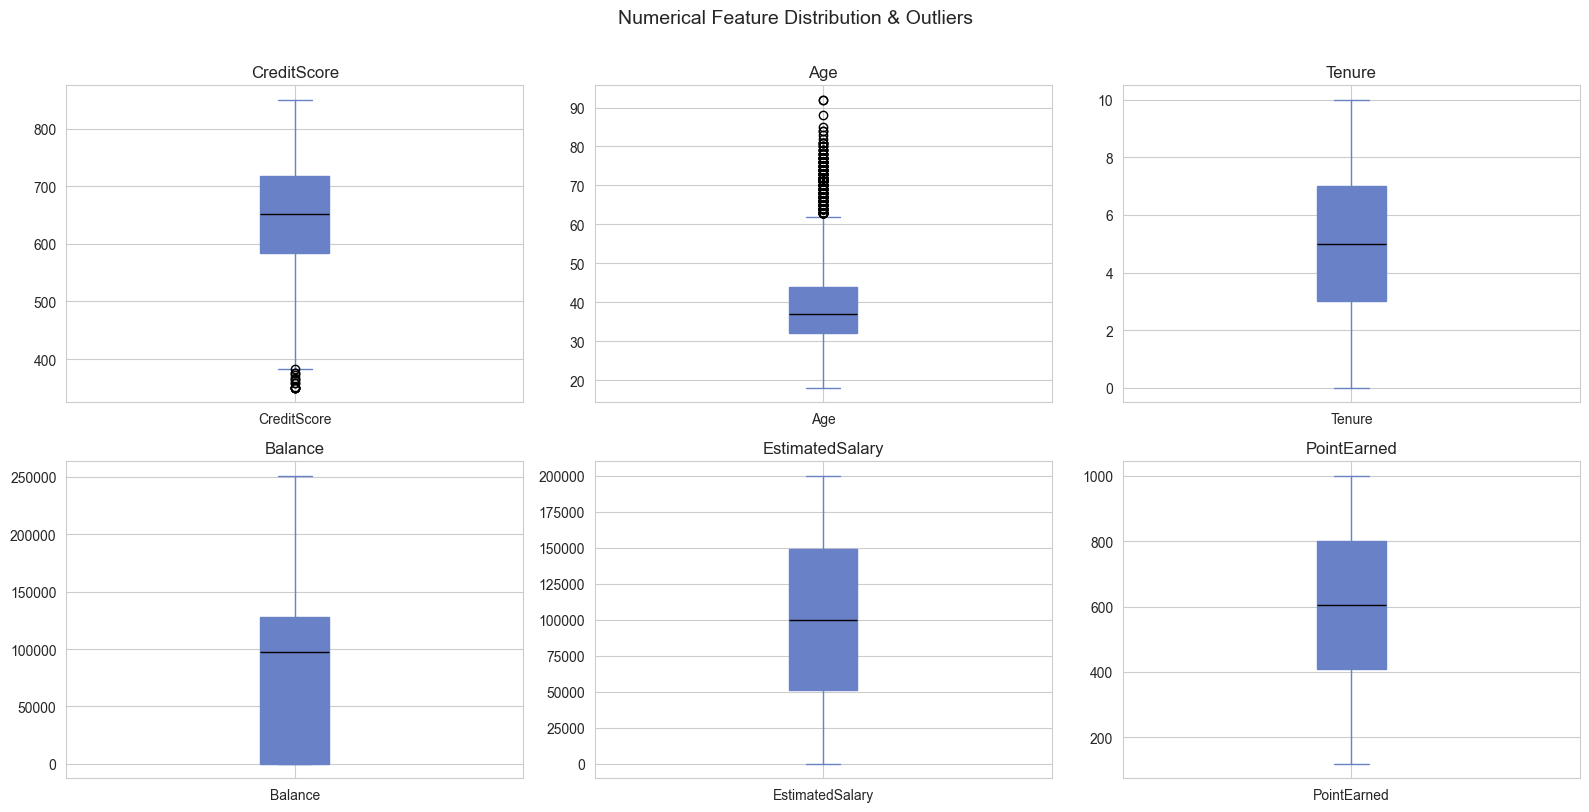

In [9]:
# Separate boxplots per feature
plot_color = palette[2]

num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary', 'PointEarned']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, col in zip(axes.flat, num_cols):
    df_clean.boxplot(
        column=col,
        ax=ax,
        patch_artist=True,
        boxprops=dict(facecolor=plot_color, color=plot_color),
        medianprops=dict(color="black"),
        whiskerprops=dict(color=plot_color),
        capprops=dict(color=plot_color)
    )
    ax.set_title(col)

plt.suptitle("Numerical Feature Distribution & Outliers", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

- CreditScore is fairly centered around 650 with a few lower-score outliers.
- Age shows noticeable outliers, indicating a few significantly older customers.
- Balance and EstimatedSalary have wide ranges, indicating diverse financial backgrounds.
- Tenure and PointEarned are fairly evenly distributed.

## 3. Exploratory Data Analysis (EDA)

We examine each feature's relationship with churn to understand what drives customers to leave.

Exited
0    0.7962
1    0.2038
Name: proportion, dtype: float64


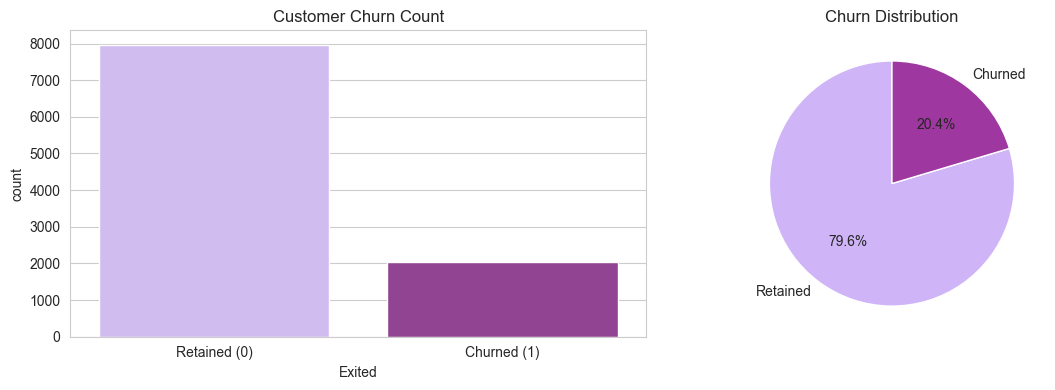

In [10]:
# Overall churn rate
churn_rate = df_clean["Exited"].value_counts(normalize=True).sort_index()
print(churn_rate)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(
    x="Exited",
    data=df_clean,
    palette=[palette[1], palette[3]],
    ax=axes[0]
)
axes[0].set_title("Customer Churn Count")
axes[0].set_xticklabels(["Retained (0)", "Churned (1)"])

# Pie chart
axes[1].pie(
    churn_rate,
    labels=["Retained", "Churned"],
    autopct="%1.1f%%",
    colors=[palette[1], palette[3]],
    startangle=90
)
axes[1].set_title("Churn Distribution")

plt.tight_layout()
plt.show()

- Churn rate remains ~20%, consistent with the summary statistics observed earlier, confirming a moderately imbalanced target variable.

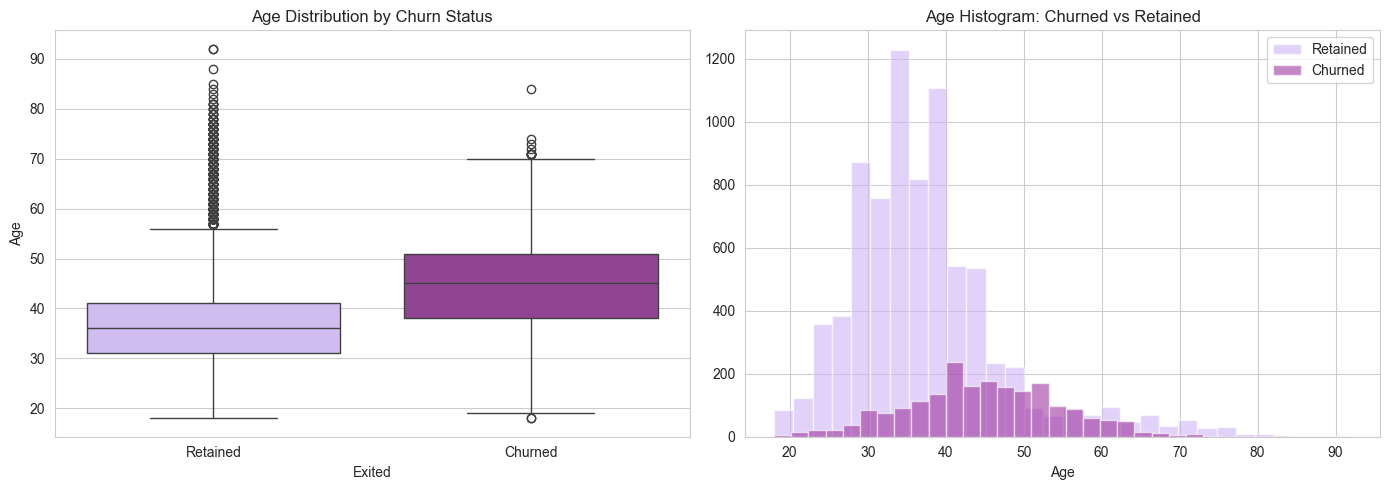

             mean  median
Exited                   
0       37.408063    36.0
1       44.835623    45.0


In [11]:
# Age analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sns.boxplot(
    x="Exited",
    y="Age",
    
    data=df_clean,
    palette=[palette[1], palette[3]],
    ax=axes[0]
)
axes[0].set_title("Age Distribution by Churn Status")
axes[0].set_xticklabels(["Retained", "Churned"])

# Histogram overlay
df_clean[df_clean["Exited"] == 0]["Age"].hist(
    bins=30,
    alpha=0.6,
    label="Retained",
    color=palette[1],
    ax=axes[1]
)

df_clean[df_clean["Exited"] == 1]["Age"].hist(
    bins=30,
    alpha=0.6,
    label="Churned",
    color=palette[3],
    ax=axes[1]
)

axes[1].set_title("Age Histogram: Churned vs Retained")
axes[1].set_xlabel("Age")
axes[1].legend()

plt.tight_layout()
plt.show()

print(df_clean.groupby("Exited")["Age"].agg(["mean", "median"]))

- Churned customers are significantly older (avg 45) vs retained customers (avg 37).  
- Middle-aged customers (40–60) are the highest churn risk group.

   Gender    Exited
0  Female  0.250715
1    Male  0.164743


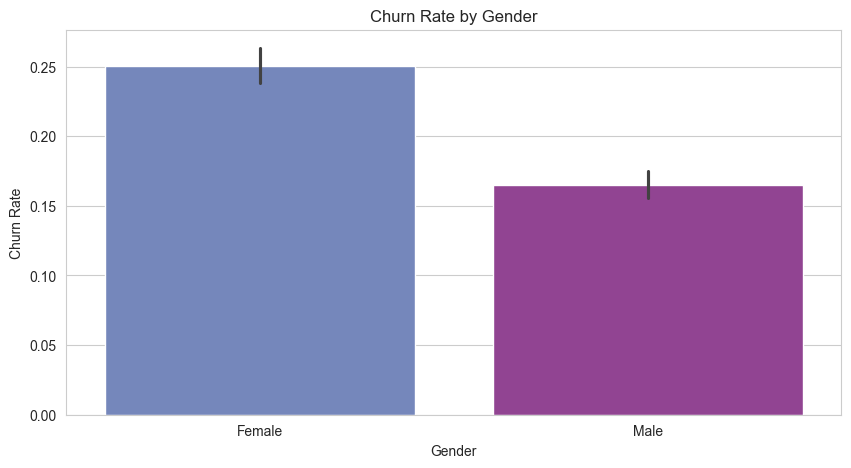

In [12]:
# Gender analysis
churn_by_gender = df_clean.groupby("Gender")["Exited"].mean().reset_index()
print(churn_by_gender)

sns.barplot(
    x="Gender", 
    y="Exited", 
    data=df_clean, 
    palette=[palette[2], palette[3]])
plt.title("Churn Rate by Gender")
plt.ylabel("Churn Rate")
plt.show()

- Female customers churn at a higher rate (25%) compared to males (16%).

  Geography    Exited
0    France  0.161747
1   Germany  0.324432
2     Spain  0.166734


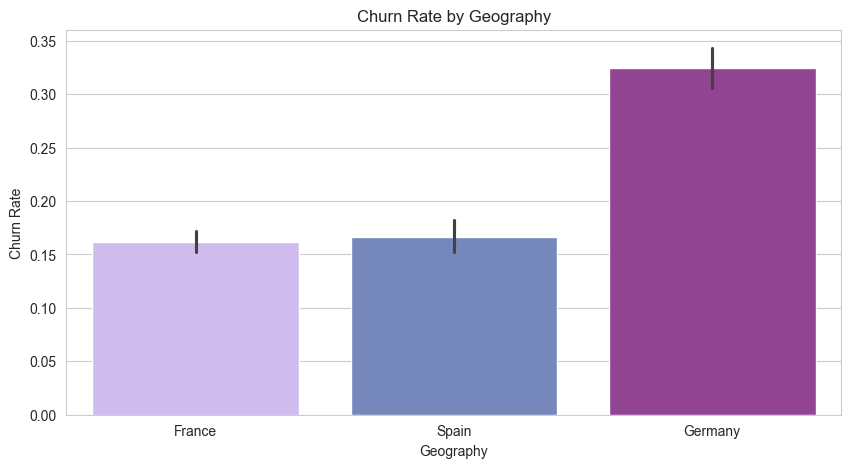

In [13]:
# Geography analysis
churn_by_geo = df_clean.groupby("Geography")["Exited"].mean().reset_index()
print(churn_by_geo)

sns.barplot(
    x="Geography", 
    y="Exited", 
    data=df_clean, 
    palette=[palette[1], palette[2], palette[3]])
plt.title("Churn Rate by Geography")
plt.ylabel("Churn Rate")
plt.show()

- Germany has the highest churn rate (32%), nearly double France and Spain (16%).  

   NumOfProducts    Exited
0              1  0.277144
1              2  0.076035
2              3  0.827068
3              4  1.000000


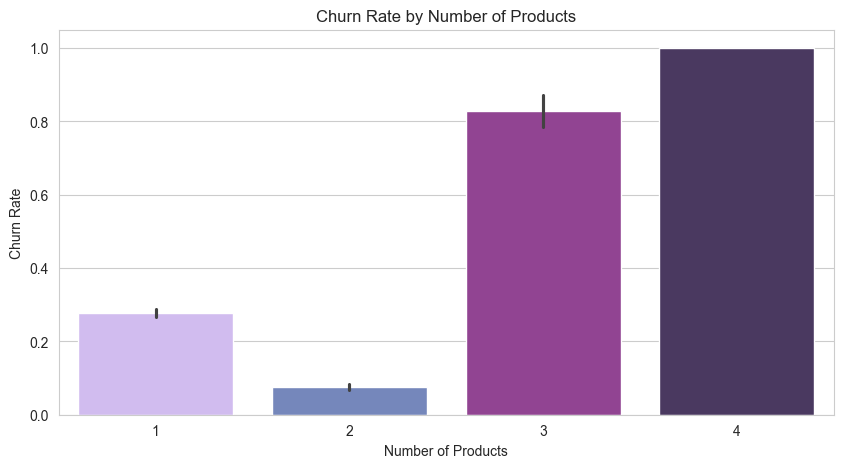

In [14]:
# Churn rate by Number of Products
churn_by_prod = df_clean.groupby("NumOfProducts")["Exited"].mean().reset_index()
print(churn_by_prod)

sns.barplot(
    x="NumOfProducts", 
    y="Exited", 
    data=df_clean, 
    palette=[palette[1], palette[2], palette[3],palette[4]])
plt.title("Churn Rate by Number of Products")
plt.ylabel("Churn Rate")
plt.xlabel("Number of Products")
plt.show()

- Customers with 1 product have moderate churn.
- Customers with 2 products are the most loyal.
- Customers with 3 products have high churn while 4 products churn at nearly 100%, which is counterintuitive.

   IsActiveMember    Exited
0               0  0.268715
1               1  0.142691
   Complain    Exited
0         0  0.000503
1         1  0.995108


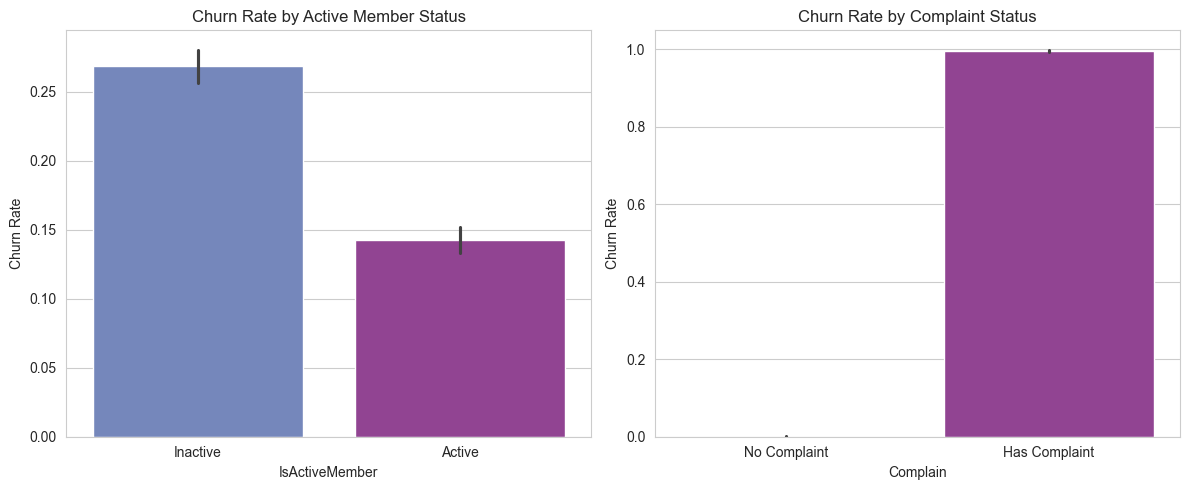

In [15]:
churn_by_active = df_clean.groupby("IsActiveMember")["Exited"].mean().reset_index()
print(churn_by_active)

churn_by_complain = df_clean.groupby("Complain")["Exited"].mean().reset_index()
print(churn_by_complain)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Churn rate by Active-Inactive member
sns.barplot(x="IsActiveMember", y="Exited", data=df_clean,
            palette=[palette[2], palette[3]], ax=axes[0])
axes[0].set_title("Churn Rate by Active Member Status")
axes[0].set_xticklabels(["Inactive", "Active"])
axes[0].set_ylabel("Churn Rate")

# Churn rate by Complain
sns.barplot(x="Complain", y="Exited", data=df_clean,
            palette=[palette[2], palette[3]], ax=axes[1])
axes[1].set_title("Churn Rate by Complaint Status")
axes[1].set_xticklabels(["No Complaint", "Has Complaint"])
axes[1].set_ylabel("Churn Rate")

plt.tight_layout()
plt.show()

- Inactive members churn at 27% vs active members at 14%.
- Customers with complaints churn at 99%, this is by far the strongest churn predictor in the dataset.

   SatisfactionScore    Exited
0                  1  0.200311
1                  2  0.217974
2                  3  0.196376
3                  4  0.206175
4                  5  0.198104
   CardType    Exited
0   DIAMOND  0.217790
1      GOLD  0.192646
2  PLATINUM  0.203607
3    SILVER  0.201122


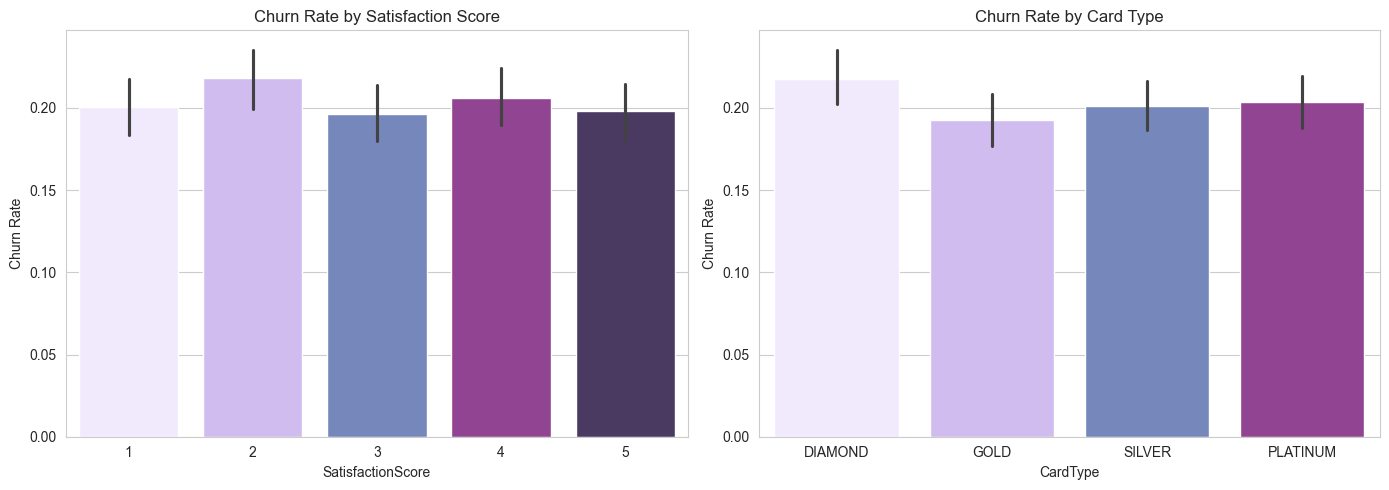

In [16]:
churn_by_satisfaction = df_clean.groupby("SatisfactionScore")["Exited"].mean().reset_index()
print(churn_by_satisfaction)

churn_by_cardtype = df_clean.groupby("CardType")["Exited"].mean().reset_index()
print(churn_by_cardtype)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn rate by SatisfactionScore
sns.barplot(x="SatisfactionScore", y="Exited", data=df_clean,
            palette=palette, ax=axes[0])
axes[0].set_title("Churn Rate by Satisfaction Score")
axes[0].set_ylabel("Churn Rate")

# Churn rate by CardType
sns.barplot(x="CardType", y="Exited", data=df_clean,
            palette=palette, ax=axes[1])
axes[1].set_title("Churn Rate by Card Type")
axes[1].set_ylabel("Churn Rate")

plt.tight_layout()
plt.show()

- Satisfaction score shows no clear linear relationship with churn, all score levels show similar churn rates.  
- Card type also shows minimal difference in churn.

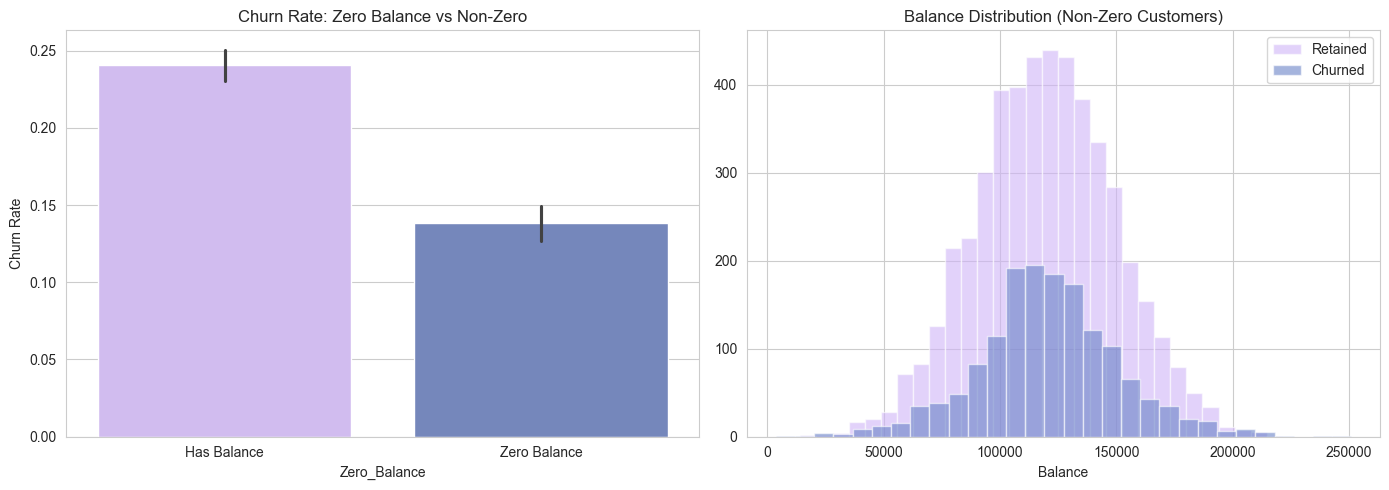

In [17]:
# Balance analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Zero balance customers
df_clean["Zero_Balance"] = (df_clean["Balance"] == 0).astype(int)
sns.barplot(x="Zero_Balance", y="Exited", data=df_clean,
            palette=[palette[1], palette[2]], ax=axes[0])
axes[0].set_title("Churn Rate: Zero Balance vs Non-Zero")
axes[0].set_xticklabels(["Has Balance", "Zero Balance"])
axes[0].set_ylabel("Churn Rate")

# Balance distribution by churn
df_nonzero = df_clean[df_clean["Balance"] > 0]
df_nonzero[df_nonzero["Exited"] == 0]["Balance"].hist(bins=30, alpha=0.6,
                                                        label="Retained", color=palette[1], ax=axes[1])
df_nonzero[df_nonzero["Exited"] == 1]["Balance"].hist(bins=30, alpha=0.6,
                                                        label="Churned", color=palette[2], ax=axes[1])
axes[1].set_title("Balance Distribution (Non-Zero Customers)")
axes[1].set_xlabel("Balance")
axes[1].legend()

plt.tight_layout()
plt.show()

- Customers with a non-zero balance churn more than zero-balance customers.  
- Among non-zero balance customers, churned customers tend to have higher balances.  

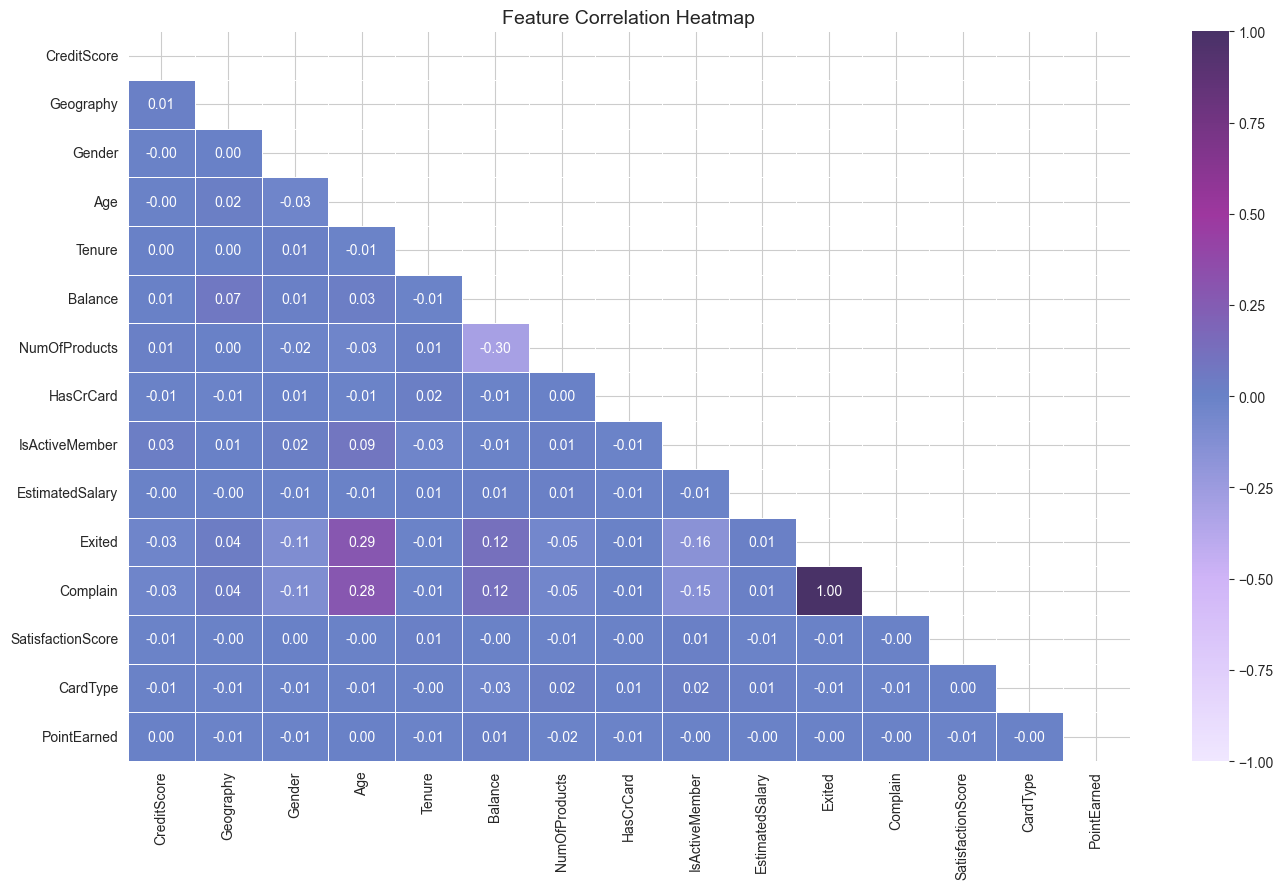

In [18]:
# Correlation heatmap
from matplotlib.colors import LinearSegmentedColormap

cmap_custom = LinearSegmentedColormap.from_list("custom_palette", palette)

le = LabelEncoder()
df_enc = df_clean.drop(columns=["Zero_Balance"])  # drop the temp column
for col in ["Geography", "Gender", "CardType"]:
    df_enc[col] = le.fit_transform(df_enc[col])

plt.figure(figsize=(14, 9))
corr = df_enc.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap=cmap_custom,   # ← your palette used here
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

- `Complain` ~0.99 — Almost perfectly predicts churn
- `Age` ~0.29 — Moderate positive correlation
- `IsActiveMember` ~0.16 — Inactive members more likely to churn
- `Balance` ~0.12 — Higher balance slightly increases churn
- `NumOfProducts` mild correlation due to the 3–4 product effect

## 4. Feature Engineering

We create new features to help the model capture patterns that raw features may miss.

In [19]:
df_model = df_enc.copy()

# 1. Balance-to-Salary ratio : measures financial dependence on the bank
df_model["Balance_Salary_Ratio"] = df_model["Balance"] / (df_model["EstimatedSalary"] + 1)

# 2. Zero balance flag : already shown to be meaningful
df_model["Has_Zero_Balance"] = (df_model["Balance"] == 0).astype(int)

# 3. Age group : captures lifecycle stage effects
df_model["Age_Group"] = pd.cut(df_model["Age"],
                                bins=[0, 30, 45, 60, 100],
                                labels=[0, 1, 2, 3]).astype(int)

# 4. Customer engagement score : combines activity signals
df_model["Engagement_Score"] = (df_model["IsActiveMember"] +
                                  df_model["NumOfProducts"] +
                                  (df_model["Tenure"] / df_model["Tenure"].max()))

# 5. High-value flag : customers with balance AND high salary
df_model["High_Value"] = ((df_model["Balance"] > df_model["Balance"].median()) &
                           (df_model["EstimatedSalary"] > df_model["EstimatedSalary"].median())).astype(int)

print("New features added. Shape:", df_model.shape)
df_model.head()

New features added. Shape: (10000, 20)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,SatisfactionScore,CardType,PointEarned,Balance_Salary_Ratio,Has_Zero_Balance,Age_Group,Engagement_Score,High_Value
0,619,0,0,42,2,0.00,1,1,1,101348.88,1,1,2,0,464,0.000000,1,1,2.2,0
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0,1,3,0,456,0.744670,0,1,2.1,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1,1,3,0,377,1.401362,0,1,3.8,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0,0,5,1,350,0.000000,1,1,2.1,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0,0,5,1,425,1.587035,0,1,2.2,0


In [20]:
# Saved the cleaned csv
df_model.to_csv("churn_model.csv", index=False)
df_model = pd.read_csv("churn_model.csv")
print("Feature Engineered data saved. Shape:", df_clean.shape)

Feature Engineered data saved. Shape: (10000, 16)


## 5. Modeling

#### Handling Class Imbalance 
Since only ~20% of customers churned, a naive model would just predict "retained" and get 80% accuracy while missing all churners.  
We oversample the minority class (churned customers) to give the model balanced training data.

#### Data Leakage Warning

During initial model runs, I achieved near‑perfect accuracy and ROC‑AUC (~0.99).  
This was a red flag: the `Complain` feature has a correlation of ~0.99 with `Exited`.  
In this dataset, almost every customer who filed a complaint churned, and almost every churner had filed a complaint.

In a real‑world deployment, complaint data would not be available at prediction time (a customer would need to leave before we know they complained). Using this feature would therefore create **data leakage** – the model would learn a rule that works on historical data but fails on new data.

**Solution:** I have excluded `Complain` from the training features. The corrected models below produce realistic results.

In [21]:
# Train/test split with imbalance handling

# This includes 'Complain' in features

# feature_cols = [col for col in df_model.columns if col != "Exited"]
# X = df_model[feature_cols]
# y = df_model["Exited"]

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )

# X_train_full = pd.concat([X_train, y_train], axis=1)
# majority = X_train_full[X_train_full["Exited"] == 0]
# minority = X_train_full[X_train_full["Exited"] == 1]

# minority_upsampled = resample(minority, replace=True,
#                                n_samples=len(majority), random_state=42)
# df_balanced = pd.concat([majority, minority_upsampled])

# X_train_bal = df_balanced[feature_cols]
# y_train_bal = df_balanced["Exited"]

# scaler = StandardScaler()
# X_train_sc = scaler.fit_transform(X_train_bal)
# X_test_sc = scaler.transform(X_test)

# print(f"Training set size: {X_train_sc.shape[0]} (balanced)")
# print(f"Test set size: {X_test_sc.shape[0]}")

In [22]:
# Model training with complain column included

# models = {
#     "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
#     "Random Forest":        RandomForestClassifier(n_estimators=200, random_state=42),
#     "XGBoost":              xgb.XGBClassifier(n_estimators=200, use_label_encoder=False,
#                                                eval_metric="logloss", random_state=42)
# }

# results = {}
# for name, model in models.items():
#     model.fit(X_train_sc, y_train_bal)
#     y_pred = model.predict(X_test_sc)
#     y_prob = model.predict_proba(X_test_sc)[:, 1]
#     auc = roc_auc_score(y_test, y_prob)
#     results[name] = {"model": model, "y_pred": y_pred, "y_prob": y_prob, "auc": auc}
#     print(f"\n{'='*40}")
#     print(f"Model: {name}")
#     print(f"ROC-AUC: {auc:.4f}")
#     print(classification_report(y_test, y_pred, target_names=["Retained", "Churned"]))

In [23]:
# Train/test split with imbalance handling
# Excluding 'Complain' from training features

feature_cols = [col for col in df_model.columns
                if col not in ["Exited", "Complain"]]

X = df_model[feature_cols]
y = df_model["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Oversample minority class in training set only (not test set)
X_train_full = pd.concat([X_train, y_train], axis=1)
majority = X_train_full[X_train_full["Exited"] == 0]
minority = X_train_full[X_train_full["Exited"] == 1]

minority_upsampled = resample(minority, replace=True,
                               n_samples=len(majority), random_state=42)
df_balanced = pd.concat([majority, minority_upsampled])

X_train_bal = df_balanced[feature_cols]
y_train_bal = df_balanced["Exited"]

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_bal)
X_test_sc  = scaler.transform(X_test)

print(f"Features used ({len(feature_cols)}): {feature_cols}")
print(f"\nTraining set: {X_train_sc.shape[0]} samples (balanced)")
print(f"Test set:     {X_test_sc.shape[0]} samples")
print(f"\nClass distribution in test set:")
print(y_test.value_counts())

Features used (18): ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'SatisfactionScore', 'CardType', 'PointEarned', 'Balance_Salary_Ratio', 'Has_Zero_Balance', 'Age_Group', 'Engagement_Score', 'High_Value']

Training set: 12740 samples (balanced)
Test set:     2000 samples

Class distribution in test set:
Exited
0    1592
1     408
Name: count, dtype: int64


In [24]:
# Corrected Model Training
# Excluding 'Complain'

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":        RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost":              xgb.XGBClassifier(n_estimators=200, use_label_encoder=False,
                                               eval_metric="logloss", random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_sc, y_train_bal)
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)

    results[name] = {
        "model":  model,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "auc":    auc
    }

    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"ROC-AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred,
                                 target_names=["Retained", "Churned"]))

# Summary comparison table
print("\n" + "="*50)
print("MODEL COMPARISON SUMMARY")
print("="*50)
summary = pd.DataFrame({
    name: {
        "ROC-AUC":  f"{res['auc']:.4f}",
        "Accuracy": f"{(res['y_pred'] == y_test).mean():.4f}"
    }
    for name, res in results.items()
}).T
print(summary)


Model: Logistic Regression
ROC-AUC: 0.7719
              precision    recall  f1-score   support

    Retained       0.91      0.69      0.79      1592
     Churned       0.38      0.72      0.49       408

    accuracy                           0.70      2000
   macro avg       0.64      0.71      0.64      2000
weighted avg       0.80      0.70      0.73      2000


Model: Random Forest
ROC-AUC: 0.8619
              precision    recall  f1-score   support

    Retained       0.89      0.94      0.92      1592
     Churned       0.71      0.54      0.61       408

    accuracy                           0.86      2000
   macro avg       0.80      0.74      0.77      2000
weighted avg       0.85      0.86      0.85      2000


Model: XGBoost
ROC-AUC: 0.8339
              precision    recall  f1-score   support

    Retained       0.89      0.90      0.89      1592
     Churned       0.59      0.55      0.57       408

    accuracy                           0.83      2000
   macro avg  

In [25]:
import joblib

# Extract Random Forest model
rf_model_final = results["Random Forest"]["model"]

# Save model
joblib.dump(rf_model_final, "rf_model.pkl")

print("Random Forest model saved successfully.")

Random Forest model saved successfully.


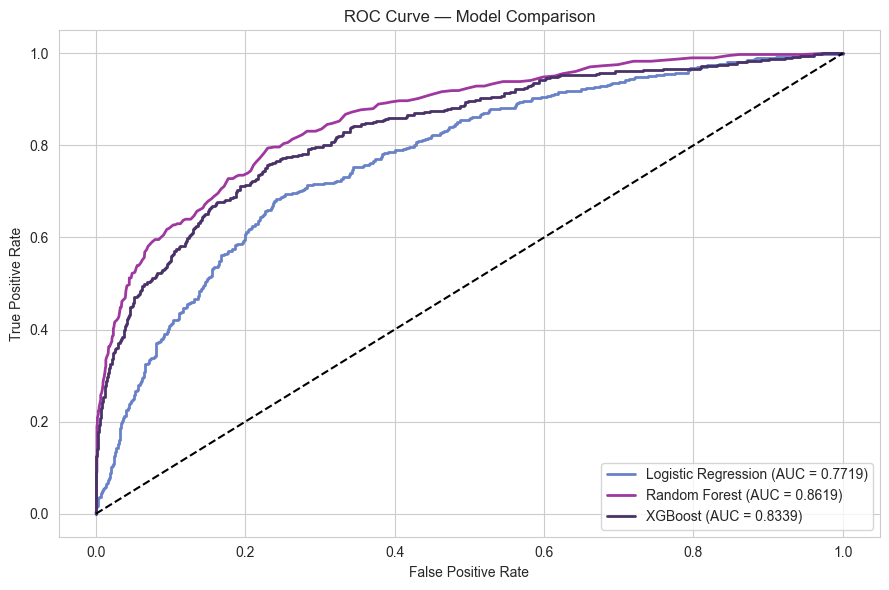

In [26]:
# ROC Curve
plt.figure(figsize=(9, 6))
colors = [palette[2],palette[3],palette[4]]
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['auc']:.4f})", color=color, lw=2)

plt.plot([0, 1], [0, 1], "k--", lw=1.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Model Comparison")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

- Random Forest achieves the highest AUC (~0.86), indicating the strongest ability to separate churned customers from retained customers.
- Logistic Regression performs moderately well but is less capable of capturing complex relationships in the data.
- XGBoost performs competitively but does not surpass Random Forest in this dataset.

Overall, Random Forest provides the best balance between true positive rate and false positive rate, making it the most suitable model for churn prediction in this analysis.

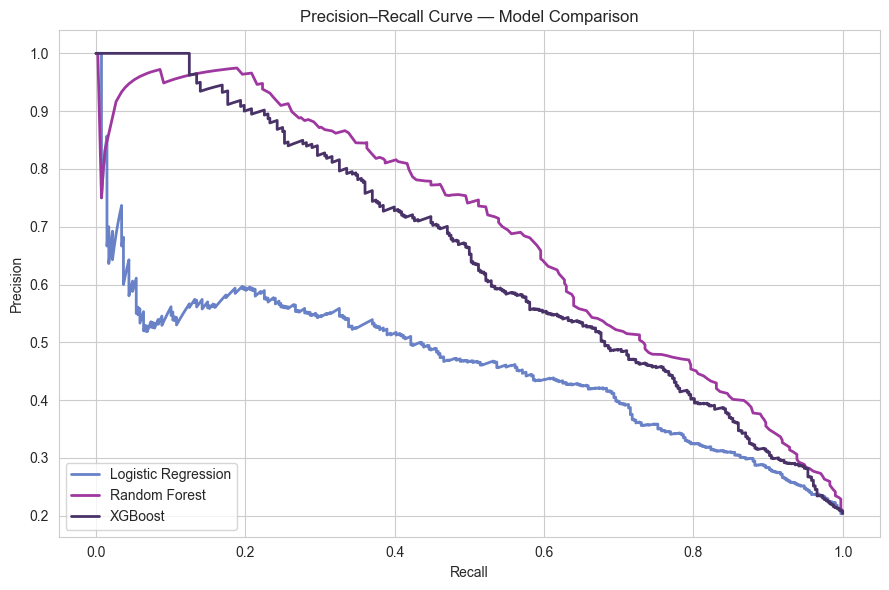

In [27]:
# Precision-Recall Curve
plt.figure(figsize=(9, 6))
colors = [palette[2], palette[3], palette[4]]

for (name, res), color in zip(results.items(), colors):
    precision, recall, _ = precision_recall_curve(y_test, res["y_prob"])
    plt.plot(recall, precision, label=name, color=color, lw=2)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Model Comparison")
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()

- Random Forest maintains the best balance between precision and recall across most thresholds.
- Logistic Regression and XGBoost show lower precision at higher recall levels, indicating weaker detection of churned customers.

Best Model: Random Forest (AUC: 0.8619)



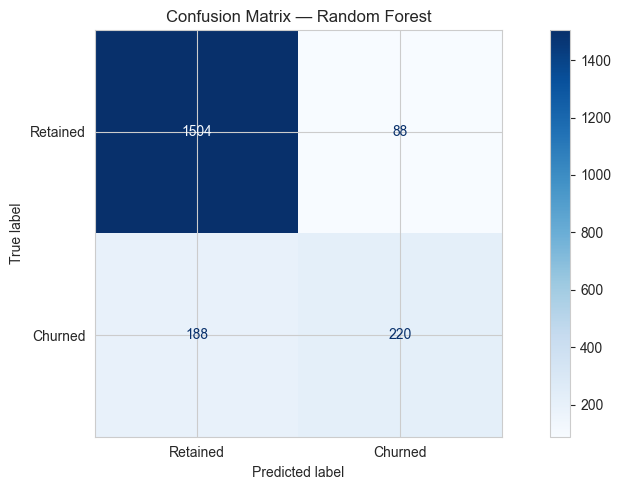

In [28]:
# Confusion Matrix
best_name = max(results, key=lambda k: results[k]["auc"])
best = results[best_name]

print(f"Best Model: {best_name} (AUC: {best['auc']:.4f})\n")

cm = confusion_matrix(y_test, best["y_pred"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Retained", "Churned"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.show()

- The model correctly identifies a large number of retained customers (1504), indicating strong performance in recognizing stable customers.
- A portion of churned customers (220) are correctly detected, but 188 churn cases are misclassified as retained.
- This indicates that the model is slightly better at predicting retention than detecting churn.

From a business perspective, missing churn cases means some customers who are likely to leave may not be targeted for retention efforts.

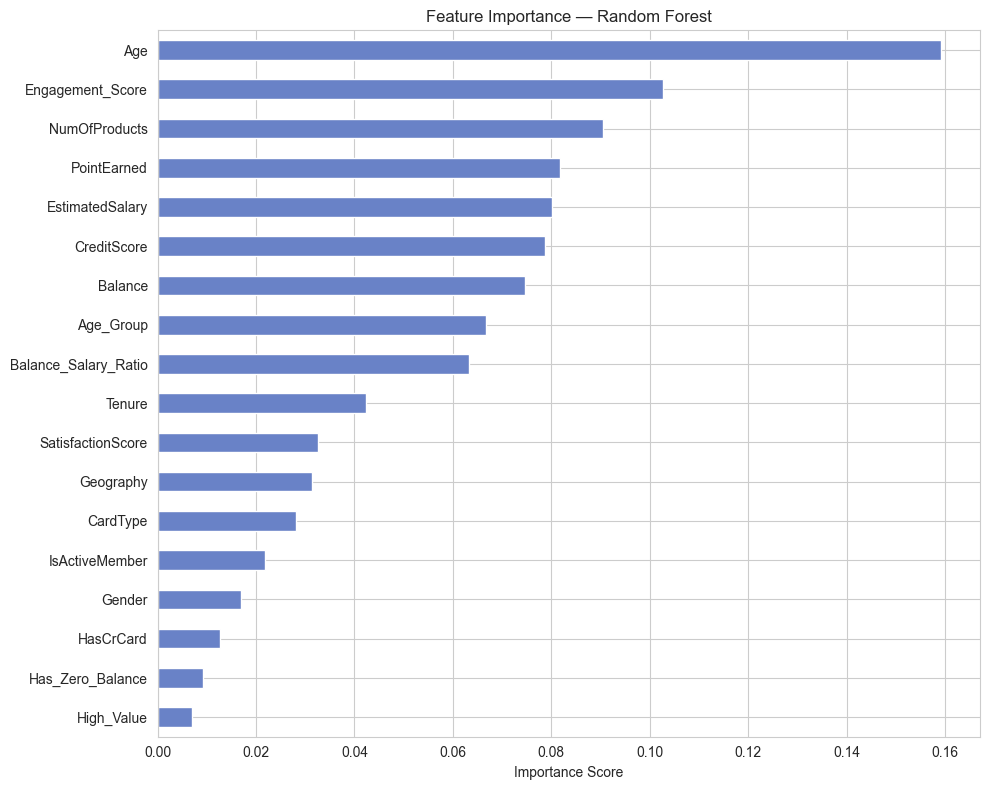

In [29]:
# Feature importance
best_model_obj = best["model"]
feat_imp = pd.Series(best_model_obj.feature_importances_,
                     index=feature_cols).sort_values(ascending=True)

feat_imp.plot(kind="barh", figsize=(10, 8), color=palette[2])
plt.title(f"Feature Importance — {best_name}")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

- Age is the strongest predictor of churn, suggesting that customer lifecycle stage plays a significant role in retention behavior.
- Number of products and account activity indicators also show strong importance, indicating that more engaged customers are less likely to churn.
- Financial attributes such as balance, estimated salary, and credit score contribute moderately to the prediction.

Overall, both demographic characteristics and banking behavior influence churn risk, suggesting that effective retention strategies should consider multiple aspects of customer activity.

## 6. Churn Risk Scoring & Customer Segmentation

Customers were assigned a churn probability using the trained Random Forest model. Based on this probability, customers were segmented into three risk tiers:

- Low Risk (0 – 0.30)
- Medium Risk (0.30 – 0.60)
- High Risk (0.60 – 1.00)

Risk_Tier
Low Risk       7253
High Risk      1838
Medium Risk     433
Name: count, dtype: int64


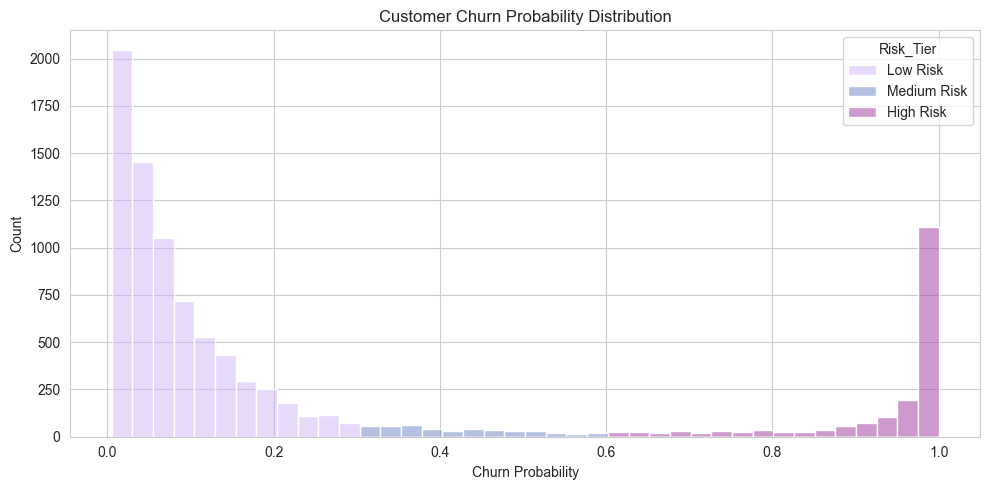

In [30]:
X_full_sc = scaler.transform(X[feature_cols])
churn_probs = best_model_obj.predict_proba(X_full_sc)[:, 1]

df_scored = df_model.copy()
df_scored["Churn_Probability"] = churn_probs
df_scored["Risk_Tier"] = pd.cut(churn_probs,
                                  bins=[0, 0.3, 0.6, 1.0],
                                  labels=["Low Risk", "Medium Risk", "High Risk"])

# Risk tier distribution
print(df_scored["Risk_Tier"].value_counts())

sns.histplot(data=df_scored, x="Churn_Probability", hue="Risk_Tier",
             bins=40, palette={"Low Risk": palette[1], "Medium Risk": palette[2], "High Risk": 
                               palette[3]})
plt.title("Customer Churn Probability Distribution")
plt.xlabel("Churn Probability")
plt.tight_layout()
plt.show()

- Results show that the majority of customers fall into the Low Risk category, indicating that most customers are predicted to remain with the bank.
- However, a smaller segment of customers is classified as High Risk, representing individuals with a significantly higher probability of churn. These customers are the most critical targets for retention strategies.

In [31]:
# Estimate revenue at risk from high-risk customers
# Using Balance as proxy for value (in a real bank, use CLV or deposit revenue)
high_risk = df_scored[df_scored["Risk_Tier"] == "High Risk"]

total_at_risk = high_risk["Balance"].sum()
avg_balance_at_risk = high_risk["Balance"].mean()
count_at_risk = len(high_risk)

print(f"High-Risk Customers: {count_at_risk}")
print(f"Total Balance at Risk: ${total_at_risk:,.0f}")
print(f"Average Balance (High Risk): ${avg_balance_at_risk:,.0f}")
print(f"\nIf 50% of high-risk customers can be retained,")
print(f"potential savings: ${total_at_risk * 0.5:,.0f}")

High-Risk Customers: 1838
Total Balance at Risk: $168,347,743
Average Balance (High Risk): $91,593

If 50% of high-risk customers can be retained,
potential savings: $84,173,871


- 1,838 customers are identified as high churn risk, representing a significant portion of potential churn.
- These customers collectively hold approximately 168M in account balances, indicating substantial financial exposure if they leave.
- If the bank successfully retains even 50% of these customers, it could potentially protect around 84M in deposits, highlighting the practical value of churn prediction models.

## Conclusion

- This project analyzed customer churn patterns using demographic, financial, and behavioral features from a retail banking dataset.
- Exploratory data analysis revealed several key patterns, including higher churn among older customers, inactive customers, and those with either very low or very high product usage.
- Multiple machine learning models were evaluated, with Random Forest providing the strongest predictive performance based on ROC and precision–recall metrics.
- Feature importance analysis showed that variables such as age, number of products, and account activity play a significant role in predicting churn.
- By assigning churn probabilities to all customers, the model enables risk-based segmentation of the customer base, helping identify high-risk customers and estimate potential financial exposure.

Overall, the analysis demonstrates how predictive modeling can be used to identify at-risk customers and support more targeted retention strategies.